# Tech Layoffs & AI Impact Analysis 2026

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib as plt
import numpy as np

In [2]:
df=pd.read_csv("tech_layoffs_2026_tracker.csv")
df

,company,layoff_date,jobs_cut,pct_workforce_cut,sector,country,hq_city,ai_cited,reason_stated,company_revenue_2025_bn,...,layoffs_2024,layoffs_2025,verified_source,month,quarter,region,layoff_size_category,stock_reaction,laid_off_vs_headcount_pct,data_as_of
0,Amazon,2026-01-15,16000,2.7,E-Commerce/Cloud,USA,Seattle,False,Reduce bureaucracy and management layers,716.9,...,4000,14000,CNBC / NetworkWorld,January 2026,Q1 2026,North America,Mega (5K+),Positive,1.03,"March 18, 2026"
1,Block,2026-02-28,4000,40.0,Fintech,USA,San Francisco,True,AI tools replace roles enabling smaller teams,22.4,...,0,1000,CNBC / Crunchbase,February 2026,Q1 2026,North America,Large (2K-5K),Positive,40.00,"March 18, 2026"
2,Meta Reality Labs,2026-01-20,1500,10.0,Social Media/VR,USA,Menlo Park,True,Pivot from metaverse to AI research,164.5,...,0,500,InformationWeek / NYT,January 2026,Q1 2026,North America,Medium (500-2K),Positive,1.90,"March 18, 2026"
3,Atlassian,2026-03-14,1600,10.0,Enterprise Software,Australia,Sydney,True,Pivot to AI-first company strategy,5.1,...,0,500,TechRepublic / Metaintro,March 2026,Q1 2026,Asia-Pacific,Medium (500-2K),Positive,10.00,"March 18, 2026"
4,Oracle,2026-02-01,30000,15.0,Enterprise Software,USA,Austin,True,AI data centres replace human ops,52.9,...,6000,10000,IBTimes,February 2026,Q1 2026,North America,Mega (5K+),Positive,15.00,"March 18, 2026"
5,Salesforce,2026-01-10,1000,1.4,CRM/SaaS,USA,San Francisco,True,AI-driven efficiency and restructuring,37.9,...,1000,1000,NetworkWorld / Bloomberg,January 2026,Q1 2026,North America,Medium (500-2K),Positive,1.39,"March 18, 2026"
6,Autodesk,2026-01-25,1000,9.0,Design Software,USA,San Francisco,False,Post-Ansys acquisition restructuring,5.9,...,500,1200,NetworkWorld,January 2026,Q1 2026,North America,Medium (500-2K),Positive,9.09,"March 18, 2026"
7,eBay,2026-01-28,800,5.0,E-Commerce,USA,San Jose,True,AI-forward strategy in customer ops,10.3,...,1000,1000,NetworkWorld,January 2026,Q1 2026,North America,Medium (500-2K),Positive,7.27,"March 18, 2026"
8,Pinterest,2026-02-10,675,4.0,Social Media,USA,San Francisco,True,AI-forward content and marketing strategy,3.6,...,1500,200,NetworkWorld,February 2026,Q1 2026,North America,Medium (500-2K),Positive,18.24,"March 18, 2026"
9,Ericsson,2026-01-15,1600,12.0,Telecommunications,Sweden,Stockholm,False,Declining 5G demand and cost reduction,24.3,...,3000,5000,InformationWeek / FierceNetwork,January 2026,Q1 2026,Europe,Medium (500-2K),Positive,1.52,"March 18, 2026"


 # Check Missing Values,Remove Duplicates,Convert Date Column


In [3]:
df.info

<bound method DataFrame.info of                      company layoff_date  jobs_cut  pct_workforce_cut  \
0                     Amazon  2026-01-15     16000                2.7   
1                      Block  2026-02-28      4000               40.0   
2          Meta Reality Labs  2026-01-20      1500               10.0   
3                  Atlassian  2026-03-14      1600               10.0   
4                     Oracle  2026-02-01     30000               15.0   
5                 Salesforce  2026-01-10      1000                1.4   
6                   Autodesk  2026-01-25      1000                9.0   
7                       eBay  2026-01-28       800                5.0   
8                  Pinterest  2026-02-10       675                4.0   
9                   Ericsson  2026-01-15      1600               12.0   
10                      ASML  2026-01-20      1700                3.4   
11                 ams OSRAM  2026-02-05      2000               12.0   
12                 

In [4]:
df.shape

(28, 26)

In [5]:
df.size

728

In [6]:
df.columns

Index(['company', 'layoff_date', 'jobs_cut', 'pct_workforce_cut', 'sector',
       'country', 'hq_city', 'ai_cited', 'reason_stated',
       'company_revenue_2025_bn', 'pre_layoff_headcount',
       'stock_change_day_pct', 'simultaneous_ai_investment_bn',
       'roles_most_affected', 'replacement_roles', 'ceo_quote', 'layoffs_2024',
       'layoffs_2025', 'verified_source', 'month', 'quarter', 'region',
       'layoff_size_category', 'stock_reaction', 'laid_off_vs_headcount_pct',
       'data_as_of'],
      dtype='object')

In [7]:
df.head()

,company,layoff_date,jobs_cut,pct_workforce_cut,sector,country,hq_city,ai_cited,reason_stated,company_revenue_2025_bn,...,layoffs_2024,layoffs_2025,verified_source,month,quarter,region,layoff_size_category,stock_reaction,laid_off_vs_headcount_pct,data_as_of
0,Amazon,2026-01-15,16000,2.7,E-Commerce/Cloud,USA,Seattle,False,Reduce bureaucracy and management layers,716.9,...,4000,14000,CNBC / NetworkWorld,January 2026,Q1 2026,North America,Mega (5K+),Positive,1.03,"March 18, 2026"
1,Block,2026-02-28,4000,40.0,Fintech,USA,San Francisco,True,AI tools replace roles enabling smaller teams,22.4,...,0,1000,CNBC / Crunchbase,February 2026,Q1 2026,North America,Large (2K-5K),Positive,40.00,"March 18, 2026"
2,Meta Reality Labs,2026-01-20,1500,10.0,Social Media/VR,USA,Menlo Park,True,Pivot from metaverse to AI research,164.5,...,0,500,InformationWeek / NYT,January 2026,Q1 2026,North America,Medium (500-2K),Positive,1.90,"March 18, 2026"
3,Atlassian,2026-03-14,1600,10.0,Enterprise Software,Australia,Sydney,True,Pivot to AI-first company strategy,5.1,...,0,500,TechRepublic / Metaintro,March 2026,Q1 2026,Asia-Pacific,Medium (500-2K),Positive,10.00,"March 18, 2026"
4,Oracle,2026-02-01,30000,15.0,Enterprise Software,USA,Austin,True,AI data centres replace human ops,52.9,...,6000,10000,IBTimes,February 2026,Q1 2026,North America,Mega (5K+),Positive,15.00,"March 18, 2026"


In [8]:
df.tail()

,company,layoff_date,jobs_cut,pct_workforce_cut,sector,country,hq_city,ai_cited,reason_stated,company_revenue_2025_bn,...,layoffs_2024,layoffs_2025,verified_source,month,quarter,region,layoff_size_category,stock_reaction,laid_off_vs_headcount_pct,data_as_of
23,Workday,2026-01-28,2200,8.5,Enterprise SaaS,USA,Pleasanton CA,True,AI investment and office space reduction,8.5,...,1750,1750,Computerworld,January 2026,Q1 2026,North America,Large (2K-5K),Positive,8.53,"March 18, 2026"
24,Ergo Insurance,2026-03-01,200,2.0,Insurance,Germany,Dusseldorf,True,AI automates insurance tasks,0.0,...,0,0,Intellizence,March 2026,Q1 2026,Europe,Small (<500),Neutral,2.22,"March 18, 2026"
25,Algoma Steel,2026-03-07,1000,20.0,Manufacturing,Canada,Sault Ste Marie,False,Blast furnace closure,2.8,...,0,0,Intellizence,March 2026,Q1 2026,North America,Medium (500-2K),Negative,20.00,"March 18, 2026"
26,Meta Platforms (Planned),2026-03-13,16000,20.0,Social Media/AI,USA,Menlo Park,True,Offset AI infrastructure costs,164.5,...,0,0,CNBC / Reuters / IBTimes,March 2026,Q1 2026,North America,Mega (5K+),Positive,20.25,"March 18, 2026"
27,Algoma Steel,2026-03-23,1000,20.0,Manufacturing,Canada,Sault Ste Marie,False,Blast furnace closure effective,2.8,...,0,0,Intellizence,March 2026,Q1 2026,North America,Medium (500-2K),Negative,20.00,"March 18, 2026"


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 26 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   company                        28 non-null     object 
 1   layoff_date                    28 non-null     object 
 2   jobs_cut                       28 non-null     int64  
 3   pct_workforce_cut              28 non-null     float64
 4   sector                         28 non-null     object 
 5   country                        28 non-null     object 
 6   hq_city                        28 non-null     object 
 7   ai_cited                       28 non-null     bool   
 8   reason_stated                  28 non-null     object 
 9   company_revenue_2025_bn        28 non-null     float64
 10  pre_layoff_headcount           28 non-null     int64  
 11  stock_change_day_pct           28 non-null     float64
 12  simultaneous_ai_investment_bn  28 non-null     float

In [10]:
df.describe()

,jobs_cut,pct_workforce_cut,company_revenue_2025_bn,pre_layoff_headcount,stock_change_day_pct,simultaneous_ai_investment_bn,layoffs_2024,layoffs_2025,laid_off_vs_headcount_pct
count,28.000000,28.000000,28.00000,2.800000e+01,28.000000,28.000000,28.000000,28.000000,28.000000
mean,3612.357143,10.639286,63.62500,1.076631e+05,0.832143,14.046429,944.642857,1951.785714,10.452143
std,6546.591373,10.433505,139.44986,2.915339e+05,1.742721,34.751824,1615.511574,3328.482085,10.719330
min,50.000000,0.100000,0.00000,2.500000e+03,-2.100000,0.000000,0.000000,0.000000,0.320000
25%,989.500000,2.525000,3.50000,8.750000e+03,-0.325000,0.000000,0.000000,0.000000,1.975000
50%,1000.000000,7.750000,9.40000,1.850000e+04,0.650000,0.450000,0.000000,500.000000,7.205000
75%,2050.000000,15.000000,53.90000,8.050000e+04,1.850000,2.250000,1125.000000,1812.500000,15.810000
max,30000.000000,40.000000,716.90000,1.550000e+06,5.800000,115.000000,6000.000000,14000.000000,40.000000


In [11]:
df.isnull().sum()

company                          0
layoff_date                      0
jobs_cut                         0
pct_workforce_cut                0
sector                           0
country                          0
hq_city                          0
ai_cited                         0
reason_stated                    0
company_revenue_2025_bn          0
pre_layoff_headcount             0
stock_change_day_pct             0
simultaneous_ai_investment_bn    0
roles_most_affected              0
replacement_roles                0
ceo_quote                        0
layoffs_2024                     0
layoffs_2025                     0
verified_source                  0
month                            0
quarter                          0
region                           0
layoff_size_category             0
stock_reaction                   0
laid_off_vs_headcount_pct        0
data_as_of                       0
dtype: int64

In [12]:
df.drop_duplicates(inplace=True)

In [13]:
df['layoff_date'] = pd.to_datetime(df['layoff_date'])

EDA

In [14]:
df[['company','jobs_cut']].sort_values(by='jobs_cut', ascending=False)

,company,jobs_cut
4,Oracle,30000
0,Amazon,16000
26,Meta Platforms (Planned),16000
14,Cisco,6000
18,Telefonica,5000
1,Block,4000
23,Workday,2200
13,WiseTech Global,2000
11,ams OSRAM,2000
10,ASML,1700


sector had the highest layoffs

In [15]:
df.groupby('sector')['jobs_cut'].sum().sort_values(ascending=False)

sector
Enterprise Software         31600
Social Media/AI             16000
E-Commerce/Cloud            16000
Telecommunications           6963
Networking/Cybersecurity     6000
Fintech                      4000
Semiconductors               3700
Enterprise SaaS              2200
Logistics Software           2000
Manufacturing                2000
Social Media/VR              1500
Automotive Tech              1000
CRM/SaaS                     1000
Grocery Tech                 1000
Design Software              1000
Retail Pharmacy              1000
Interior Design Tech         1000
EV Batteries                  958
E-Commerce                    800
Social Media                  675
Cybersecurity                 500
Insurance                     200
AI Research                    50
Name: jobs_cut, dtype: int64

country had the most layoffs

In [16]:
df.groupby('country')['jobs_cut'].sum()

country
Australia       3600
Austria         2000
Canada          2000
Germany          200
India           1000
Netherlands     1700
Spain           5000
Sweden          1600
UK              1000
USA            83046
Name: jobs_cut, dtype: int64

AI-Cited vs Non-AI Layoffs

In [17]:
df.groupby('ai_cited')['jobs_cut'].sum()

ai_cited
False    39121
True     62025
Name: jobs_cut, dtype: int64

In [18]:
df.groupby('month')['jobs_cut'].sum()

month
February 2026    46588
January 2026     32800
March 2026       21758
Name: jobs_cut, dtype: int64

In [19]:
df.groupby('stock_reaction')['jobs_cut'].mean()

stock_reaction
Negative    1627.625000
Neutral      416.666667
Positive    5110.294118
Name: jobs_cut, dtype: float64

In [20]:
df[['company_revenue_2025_bn','jobs_cut']].corr()

,company_revenue_2025_bn,jobs_cut
company_revenue_2025_bn,1.000000,0.434519
jobs_cut,0.434519,1.000000


# BAR CHART

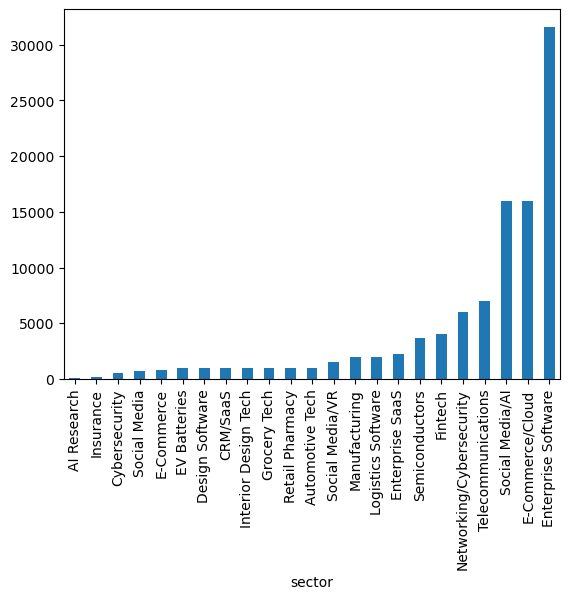

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sector_layoffs = df.groupby('sector')['jobs_cut'].sum().sort_values()
sector_layoffs.plot(kind='bar')
plt.show()

->This bar chart shows the total layoffs in different technology sectors during 2026.
->The sectors with higher bars experienced more employee layoffs compared to others.
->This analysis helps identify which industries were most affected by workforce reductions.
->The chart also provides insights into the impact of economic conditions and AI adoption across sectors.
->It makes the comparison between sectors simple and easy to understand.

# PIE CHART

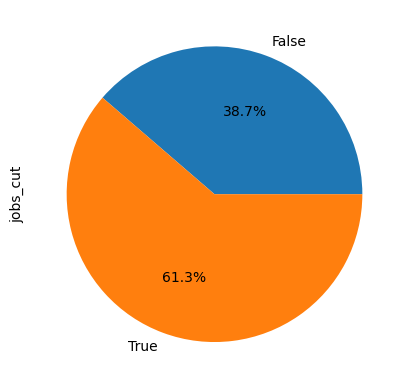

In [22]:
df.groupby('ai_cited')['jobs_cut'].sum().plot(kind='pie', autopct='%1.1f%%')
plt.show()

->This pie chart shows the percentage of layoffs related to AI and non-AI reasons.
->It helps compare how much AI contributed to workforce reductions in 2026.
->Larger pie sections represent higher employee layoffs in that category.


# HEATMAP 

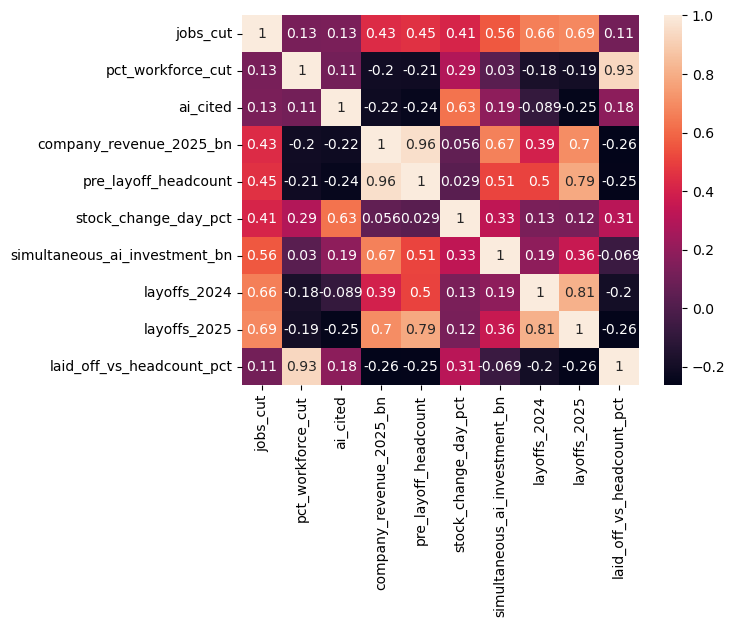

In [23]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

->This heatmap shows the correlation between numerical columns in the dataset.
->It helps identify positive and negative relationships between variables like layoffs, revenue, and workforce size.
->Darker or stronger colors indicate a higher relationship between the data columns.


# HISTOGRAM

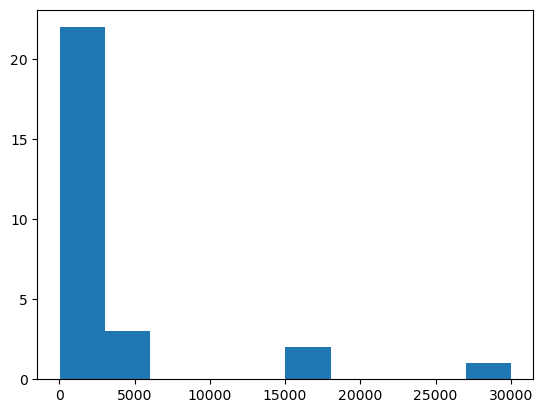

In [24]:
plt.hist(df['jobs_cut'])
plt.show()

->This histogram shows the distribution of employee layoffs across companies.
->It helps understand how frequently different layoff counts occurred in the dataset.
->Higher bars indicate that more companies had layoffs within that range.


# BOXPLOT

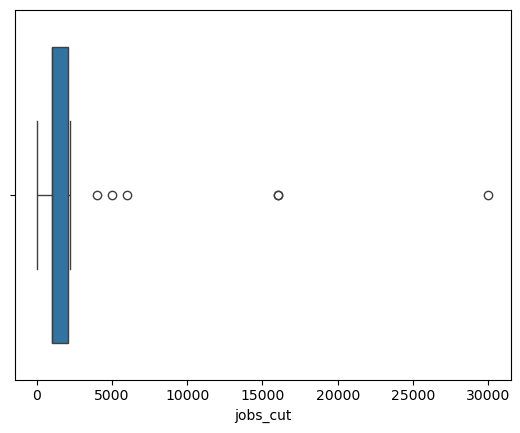

In [25]:
sns.boxplot(x=df['jobs_cut'])
plt.show()

->This boxplot shows the spread and distribution of layoff counts in the dataset.
->It helps identify outliers or companies with extremely high layoffs compared to others.
->The chart is useful for understanding variation in employee layoffs across companies.


The analysis suggests that many tech companies increased AI implementation to improve automation and business efficiency. In several cases, companies generated higher revenue or improved operational performance after adopting AI technologies. However, this also led to workforce reductions, as some manual and repetitive jobs were replaced by AI-based systems. Overall, AI adoption helped many companies optimize costs and improve productivity while reducing employee dependency.

In [26]:
df['severity'] = (df['jobs_cut'] / df['pre_layoff_headcount']) * 100

sk=df[['company','jobs_cut','pre_layoff_headcount','severity']]
sk

,company,jobs_cut,pre_layoff_headcount,severity
0,Amazon,16000,1550000,1.032258
1,Block,4000,10000,40.000000
2,Meta Reality Labs,1500,79000,1.898734
3,Atlassian,1600,16000,10.000000
4,Oracle,30000,200000,15.000000
5,Salesforce,1000,72000,1.388889
6,Autodesk,1000,11000,9.090909
7,eBay,800,11000,7.272727
8,Pinterest,675,3700,18.243243
9,Ericsson,1600,105000,1.523810


  # Conclusion

Through exploratory data analysis and visualizations, important insights were discovered regarding sector-wise layoffs, country-wise workforce reductions, AI-cited layoffs, and the relationship between company revenue and employee cuts. The feature engineering process helped measure layoff severity, providing a deeper understanding of the actual impact on organizations.

5
